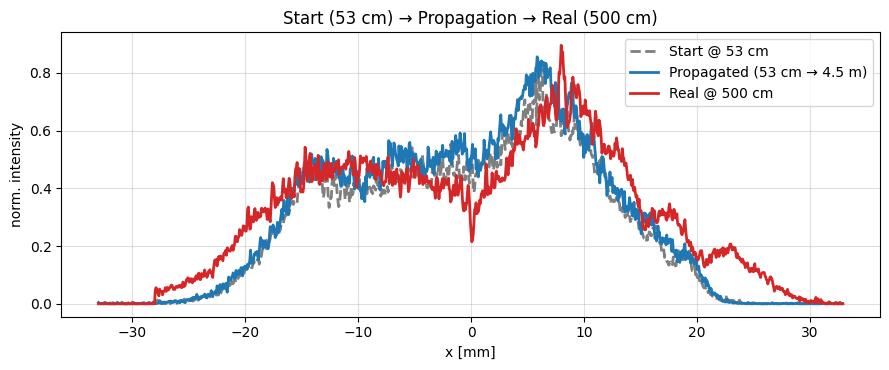

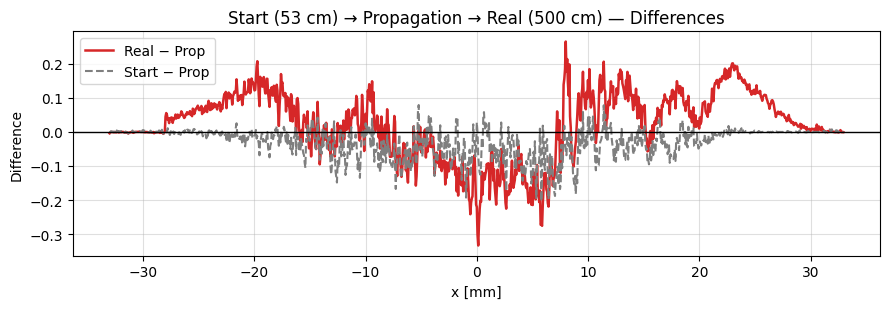

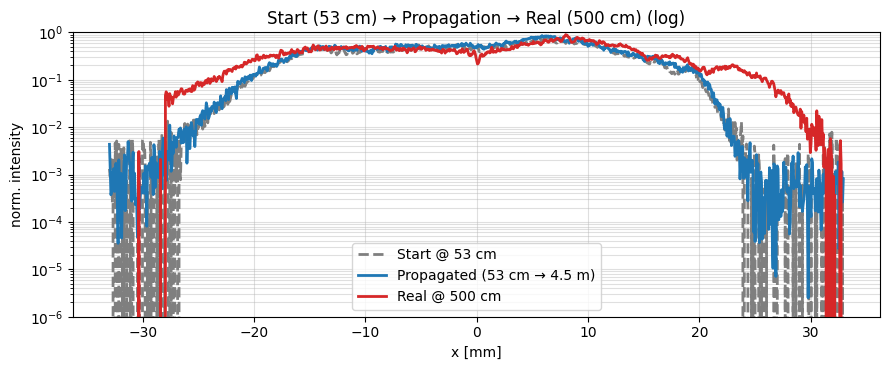

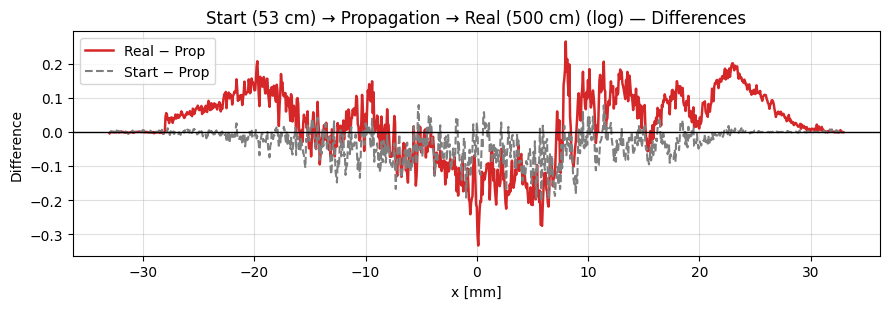

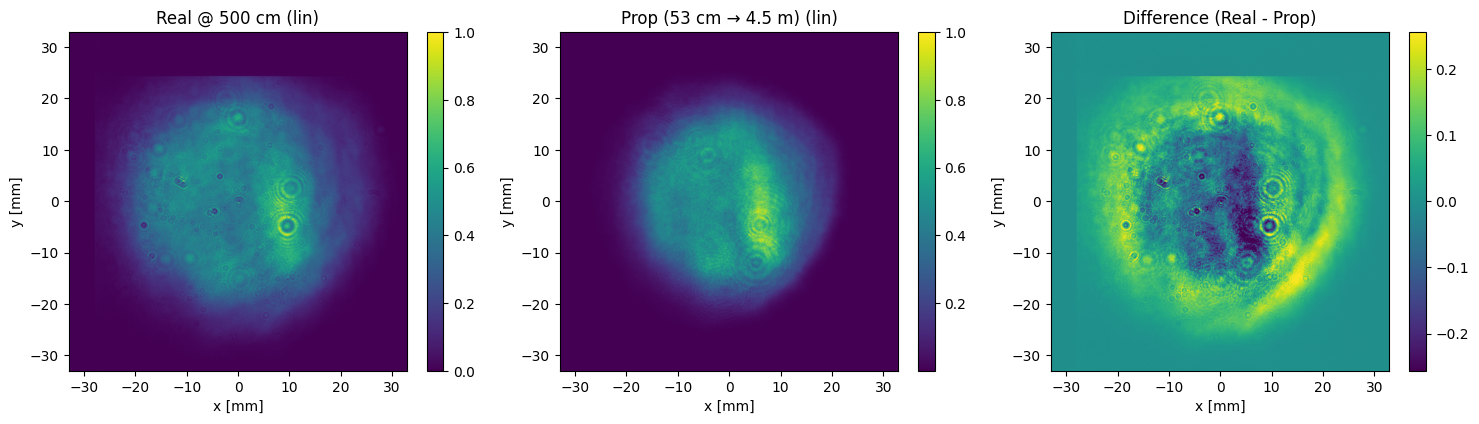

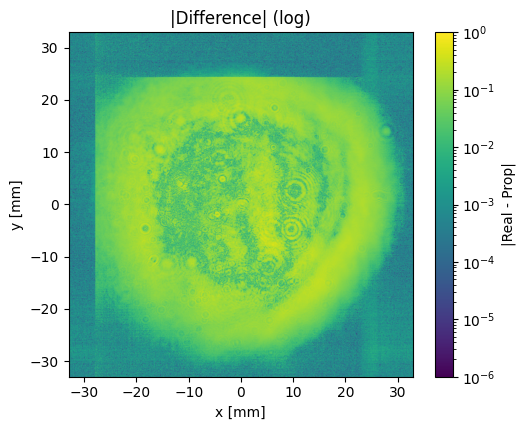


=== Difference Metrics (normalized intensities) ===
[All pixels]
  MAE   : 0.0526586
  RMSE  : 0.0798723
  NRMSE : 0.0798723
  Corr  : 0.928039

[Beam mask: I_real > 1e-2]
  MAE   : 0.0840186
  RMSE  : 0.1015
  NRMSE : 0.102526
  Corr  : 0.921196

Extra:
  Mean(|Real-Prop|) over all pixels: 0.0526586
  Max(|Real-Prop|) over all pixels : 0.53358


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os

# ==============================================================
# 1) Physik & Gitter
# ==============================================================
lam = 800e-9
BEAM_DIAM = 11e-3

N = 1024
L = 6 * BEAM_DIAM
dx = L / N
x = (np.arange(N) - N/2) * dx
X, Y = np.meshgrid(x, x)

# ==============================================================
# 2) Helpers: center, resample, normalization
# ==============================================================
def center_by_centroid(I, thresh_rel=0.2):
    I = np.asarray(I, float)
    if I.max() <= 0:
        return I
    t = thresh_rel * I.max()
    m = I > t
    if not np.any(m):
        return I

    yy, xx = np.indices(I.shape)
    cx = (xx[m] * I[m]).sum() / (I[m].sum() + 1e-12)
    cy = (yy[m] * I[m]).sum() / (I[m].sum() + 1e-12)

    sx = int(round(I.shape[1] / 2 - cx))
    sy = int(round(I.shape[0] / 2 - cy))
    return np.roll(np.roll(I, sy, axis=0), sx, axis=1)

def resample_bilinear(img, new_h, new_w):
    h, w = img.shape
    if (h, w) == (new_h, new_w):
        return img.copy()

    yy = np.linspace(0, h - 1, new_h)
    xx = np.linspace(0, w - 1, new_w)

    x0 = np.floor(xx).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y0 = np.floor(yy).astype(int)
    y1 = np.clip(y0 + 1, 0, h - 1)

    wx = (xx - x0)[None, :]
    wy = (yy - y0)[:, None]

    Ia = img[y0[:, None], x0[None, :]]
    Ib = img[y0[:, None], x1[None, :]]
    Ic = img[y1[:, None], x0[None, :]]
    Id = img[y1[:, None], x1[None, :]]

    return (1 - wy) * ((1 - wx) * Ia + wx * Ib) + wy * ((1 - wx) * Ic + wx * Id)

def load_tiff_gray(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")

    try:
        import tifffile
        img = tifffile.imread(filename)
    except Exception:
        from PIL import Image
        img = np.array(Image.open(filename))

    img = np.asarray(img)

    # RGB -> gray
    if img.ndim == 3:
        if img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
        else:
            img = img[0]

    return img.astype(np.float64)

def preprocess_intensity(I, center=True, subtract_bg=True, edge_frac=0.03, thresh_rel=0.2):
    """Background abziehen + clip + optional zentrieren + auf Peak normieren."""
    I = I.astype(np.float64)

    if subtract_bg:
        edge = max(10, int(edge_frac * min(I.shape)))
        border = np.concatenate([
            I[:edge, :].ravel(),
            I[-edge:, :].ravel(),
            I[:, :edge].ravel(),
            I[:, -edge:].ravel(),
        ])
        bg = np.median(border)
        I = I - bg
        I[I < 0] = 0.0

    if center:
        I = center_by_centroid(I, thresh_rel=thresh_rel)

    peak = I.max()
    if peak > 0:
        I = I / peak

    if I.shape != (N, N):
        I = resample_bilinear(I, N, N)

    return I

# ==============================================================
# 3) ASM propagation
# ==============================================================
def propagate_asm(U0, z):
    k = 2*np.pi / lam

    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k**2 - kx**2 - ky**2 + 0j)

    H = np.exp(1j * kz * z)

    Uz = np.fft.ifft2(np.fft.fft2(U0) * H)
    return Uz

# ==============================================================
# 4) Metrics
# ==============================================================
def metrics(I_real, I_pred, mask=None):
    """Fehlermaße zwischen zwei normierten Intensitäten (0..1)."""
    if mask is None:
        mask = np.ones_like(I_real, dtype=bool)

    a = I_real[mask].ravel()
    b = I_pred[mask].ravel()

    diff = a - b
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    nrmse = rmse / (np.max(a) - np.min(a) + 1e-12)

    # Pearson correlation
    a0 = a - a.mean()
    b0 = b - b.mean()
    corr = (a0 @ b0) / (np.linalg.norm(a0) * np.linalg.norm(b0) + 1e-12)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NRMSE": nrmse,
        "Corr": corr
    }

# ==============================================================
# 5) Plot helpers: overlay + difference maps
# ==============================================================
def plot_overlay_1d(I_prop, I_real, I_start, title="", zoom_mm=None, log=False):
    mid = N//2
    x_mm = x * 1e3

    p = I_prop[mid, :]
    r = I_real[mid, :]
    s = I_start[mid, :]

    if zoom_mm is not None:
        m = np.abs(x_mm) <= zoom_mm
        x_plot = x_mm[m]
        p = p[m]
        r = r[m]
        s = s[m]
    else:
        x_plot = x_mm

    plt.figure(figsize=(9,3.8))

    plt.plot(x_plot, s, color="tab:gray", linestyle="--", linewidth=2.0,
             label="Start @ 53 cm")
    plt.plot(x_plot, p, color="tab:blue", linewidth=2.0,
             label="Propagated (53 cm → 4.5 m)")
    plt.plot(x_plot, r, color="tab:red", linewidth=2.0,
             label="Real @ 500 cm")

    if log:
        plt.yscale("log")
        plt.ylim(1e-6, 1)

    plt.xlabel("x [mm]")
    plt.ylabel("norm. intensity")
    plt.title(title)
    plt.grid(True, which="both", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Difference curves
    plt.figure(figsize=(9,3.2))
    plt.plot(x_plot, r - p, color="tab:red", linewidth=1.8, label="Real − Prop")
    plt.plot(x_plot, s - p, color="tab:gray", linewidth=1.5, linestyle="--",
             label="Start − Prop")
    plt.axhline(0, color="k", linewidth=1)
    plt.xlabel("x [mm]")
    plt.ylabel("Difference")
    plt.title(title + " — Differences")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_2d_compare(I_prop, I_real, zoom_mm=None, eps=1e-6):
    x_mm = x * 1e3

    if zoom_mm is not None:
        m = np.abs(x_mm) <= zoom_mm
        I_prop = I_prop[np.ix_(m, m)]
        I_real = I_real[np.ix_(m, m)]
        extent = [-zoom_mm, zoom_mm, -zoom_mm, zoom_mm]
    else:
        extent = [x_mm.min(), x_mm.max(), x_mm.min(), x_mm.max()]

    diff = I_real - I_prop
    absdiff = np.abs(diff)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))

    im0 = axs[0].imshow(I_real, origin="lower", extent=extent, aspect="equal")
    axs[0].set_title("Real @ 500 cm (lin)")
    plt.colorbar(im0, ax=axs[0], fraction=0.046)

    im1 = axs[1].imshow(I_prop, origin="lower", extent=extent, aspect="equal")
    axs[1].set_title("Prop (53 cm → 4.5 m) (lin)")
    plt.colorbar(im1, ax=axs[1], fraction=0.046)

    # Difference heatmap: use symmetric limits around 0
    vmax = np.percentile(np.abs(diff), 99.5) + 1e-12
    im2 = axs[2].imshow(diff, origin="lower", extent=extent, aspect="equal",
                        vmin=-vmax, vmax=vmax)
    axs[2].set_title("Difference (Real - Prop)")
    plt.colorbar(im2, ax=axs[2], fraction=0.046)

    for ax in axs:
        ax.set_xlabel("x [mm]")
        ax.set_ylabel("y [mm]")

    plt.tight_layout()
    plt.show()

    # Optional: absolute diff log view
    plt.figure(figsize=(5.5,4.4))
    plt.imshow(np.maximum(absdiff, eps), origin="lower", extent=extent, aspect="equal",
               norm=LogNorm(vmin=eps, vmax=1))
    plt.title("|Difference| (log)")
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.colorbar(label="|Real - Prop|")
    plt.tight_layout()
    plt.show()

# ==============================================================
# 6) Main
# ==============================================================
if __name__ == "__main__":

    file_53cm = "messung 53cm.tiff"
    file_500cm = "messung 500cm.tiff"   # <- ggf. Dateiname anpassen!

    z = 4.5  # [m] propagation from 53cm to ~500cm

    # --- Load + preprocess both as intensity maps (0..1) ---
    I_53 = preprocess_intensity(load_tiff_gray(file_53cm), center=True, subtract_bg=True)
    I_500 = preprocess_intensity(load_tiff_gray(file_500cm), center=True, subtract_bg=True)

    # --- Build field from 53cm and propagate ---
    U0 = np.sqrt(np.maximum(I_53, 0.0)).astype(np.complex128)
    Uz = propagate_asm(U0, z)
    I_prop = np.abs(Uz)**2
    I_prop /= I_prop.max() if I_prop.max() > 0 else 1

    # --- Compare/overlay plots ---
    plot_overlay_1d(I_prop, I_500, I_53,
                    title="Start (53 cm) → Propagation → Real (500 cm)",
                    zoom_mm=None, log=False)

    plot_overlay_1d(I_prop, I_500, I_53,
                    title="Start (53 cm) → Propagation → Real (500 cm) (log)",
                    zoom_mm=None, log=True)


    plot_2d_compare(I_prop, I_500, zoom_mm=None)

    # --- Metrics: global + beam-only mask ---
    m_all = metrics(I_500, I_prop, mask=None)

    # Beam-only mask based on real measurement threshold (e.g. >1% of peak)
    beam_mask = I_500 > 1e-2
    m_beam = metrics(I_500, I_prop, mask=beam_mask)

    print("\n=== Difference Metrics (normalized intensities) ===")
    print("[All pixels]")
    for k, v in m_all.items():
        print(f"  {k:6s}: {v:.6g}")

    print("\n[Beam mask: I_real > 1e-2]")
    for k, v in m_beam.items():
        print(f"  {k:6s}: {v:.6g}")

    # Also report mean absolute difference map (2D)
    diff_map = I_500 - I_prop
    print("\nExtra:")
    print(f"  Mean(|Real-Prop|) over all pixels: {np.mean(np.abs(diff_map)):.6g}")
    print(f"  Max(|Real-Prop|) over all pixels : {np.max(np.abs(diff_map)):.6g}")
